In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
!pip install monai nibabel -q

import os, tarfile, torch, numpy as np, random, psutil
from monai.utils import set_determinism

# ── Seeds ─────────────────────────────────────────────────────
seed = 42
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False
set_determinism(seed=seed)

# ── Chemins — UN SEUL DRIVE ───────────────────────────────────
raw_dir      = '/content/raw_dataset'
drive_dir    = '/content/drive/MyDrive/Liver_Segmentation'  # raccourci partagé inclus
preprocessed = f'{drive_dir}/preprocessed_full'
model_dir    = f'{drive_dir}/results_full'

device       = torch.device("cuda")
pixdim       = (1.5, 1.5, 1.0)
a_min, a_max = -200, 200
spatial_size = [128, 128, 96]

# Créer les dossiers si nécessaire
for split in ['Train/images', 'Train/labels', 'Test/images', 'Test/labels']:
    os.makedirs(f'{preprocessed}/{split}', exist_ok=True)
os.makedirs(model_dir, exist_ok=True)
os.makedirs(raw_dir,   exist_ok=True)

print("✅ Variables initialisées !")
print(f"   Drive      : {drive_dir}")
print(f"   Préprocessé: {preprocessed}")
print(f"   Modèle     : {model_dir}")
#print(f"   GPU        : {torch.cuda.get_device_name(0)}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 33.1 MB/s eta 0:00:00
✅ Variables initialisées !
   Drive      : /content/drive/MyDrive/Liver_Segmentation
   Préprocessé: /content/drive/MyDrive/Liver_Segmentation/preprocessed_full
   Modèle     : /content/drive/MyDrive/Liver_Segmentation/results_full


In [5]:
tar_local = f'{raw_dir}/Task03_Liver.tar'

if not os.path.exists(f'{raw_dir}/Task03_Liver'):
    if not os.path.exists(tar_local):
        print("⬇️ Téléchargement (~27GB)...")
        !wget -q --show-progress \
          "https://msd-for-monai.s3-us-west-2.amazonaws.com/Task03_Liver.tar" \
          -O {tar_local}
    print("📦 Extraction...")
    with tarfile.open(tar_local, 'r') as tar:
        tar.extractall(raw_dir)
    print("✅ Dataset extrait !")
else:
    print("✅ Dataset déjà présent dans /content/")

⬇️ Téléchargement (~27GB)...
/content/raw_datase 100%[===================>]  26.94G  37.9MB/s    in 10m 47s 
📦 Extraction...


/tmp/ipykernel_2379/3087719493.py:9: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(raw_dir)


✅ Dataset extrait !


## Vérifier le contenu des slices + filtrage des slices contenant que du background

In [6]:
import nibabel as nib

base      = f'{raw_dir}/Task03_Liver'
images_tr = sorted([f for f in os.listdir(f'{base}/imagesTr')
                    if f.endswith('.nii.gz') and not f.startswith('._')])
labels_tr = sorted([f for f in os.listdir(f'{base}/labelsTr')
                    if f.endswith('.nii.gz') and not f.startswith('._')])

all_images = [f'{base}/imagesTr/{f}' for f in images_tr]
all_labels = [f'{base}/labelsTr/{f}' for f in labels_tr]

print(f"🔍 Vérification des fichiers ({len(all_images)} patients)...")
corrompus = []
for i, (img_path, lbl_path) in enumerate(zip(all_images, all_labels)):
    try:
        nib.load(img_path).get_fdata()
        nib.load(lbl_path).get_fdata()
        print(f"  ✅ Patient {i:3d}", end='\r')
    except Exception as e:
        print(f"  ❌ Patient {i:3d} CORROMPU : {img_path.split('/')[-1]}")
        corrompus.append(i)

all_images = [img for i, img in enumerate(all_images) if i not in corrompus]
all_labels = [lbl for i, lbl in enumerate(all_labels) if i not in corrompus]
print(f"\n✅ Patients valides : {len(all_images)} (corrompus retirés : {corrompus})")

🔍 Vérification des fichiers (131 patients)...
  ✅ Patient 130
✅ Patients valides : 131 (corrompus retirés : [])


In [7]:
import nibabel as nib
import numpy as np

base = f'{raw_dir}/Task03_Liver'

print("🔍 Analyse des slices utiles par patient...\n")

z_counts = []
for i, lbl_path in enumerate(all_labels):
    lbl  = nib.load(lbl_path).get_fdata()

    # Slices contenant foie (1) ou tumeur (2)
    z_with_content = np.where(lbl.sum(axis=(0, 1)) > 0)[0]
    n_slices_total  = lbl.shape[2]
    n_slices_useful = len(z_with_content)

    z_counts.append(n_slices_useful)
    print(f"  Patient {i:3d} → total: {n_slices_total:4d} slices | utiles: {n_slices_useful:4d} | ratio: {n_slices_useful/n_slices_total*100:.0f}%")

print(f"\n📊 Statistiques :")
print(f"   Min slices utiles : {min(z_counts)}")
print(f"   Max slices utiles : {max(z_counts)}")
print(f"   Moyenne           : {int(np.mean(z_counts))}")
print(f"   Médiane           : {int(np.median(z_counts))}")

🔍 Analyse des slices utiles par patient...

  Patient   0 → total:   75 slices | utiles:   29 | ratio: 39%
  Patient   1 → total:  123 slices | utiles:   29 | ratio: 24%
  Patient   2 → total:  501 slices | utiles:  181 | ratio: 36%
  Patient   3 → total:  685 slices | utiles:  276 | ratio: 40%
  Patient   4 → total:  683 slices | utiles:  259 | ratio: 38%
  Patient   5 → total:  677 slices | utiles:  266 | ratio: 39%
  Patient   6 → total:  683 slices | utiles:  214 | ratio: 31%
  Patient   7 → total:  781 slices | utiles:  194 | ratio: 25%
  Patient   8 → total:  986 slices | utiles:  239 | ratio: 24%
  Patient   9 → total:  771 slices | utiles:  168 | ratio: 22%
  Patient  10 → total:  771 slices | utiles:  248 | ratio: 32%
  Patient  11 → total:  856 slices | utiles:  205 | ratio: 24%
  Patient  12 → total:  756 slices | utiles:  194 | ratio: 26%
  Patient  13 → total:  466 slices | utiles:  167 | ratio: 36%
  Patient  14 → total:  816 slices | utiles:  189 | ratio: 23%
  Patient  

In [8]:
# ⚠️ GUARD CLAUSE — cette cellule ne tourne que si le preprocessing n'est pas déjà fait
train_done = len(os.listdir(f'{preprocessed}/Train/images')) > 0
test_done  = len(os.listdir(f'{preprocessed}/Test/images'))  > 0

spatial_size = [128, 128, 96]

if train_done and test_done:
    print("✅ Preprocessing déjà terminé — cellule ignorée.")
    print(f"   Train : {len(os.listdir(f'{preprocessed}/Train/images'))} fichiers")
    print(f"   Test  : {len(os.listdir(f'{preprocessed}/Test/images'))} fichiers")
else:
    from monai.transforms import (
        Compose, LoadImaged, EnsureChannelFirstd, Spacingd,
        Orientationd, ScaleIntensityRanged, CropForegroundd, Resized, Lambdad
    )
    import nibabel as nib_save

    preprocess = Compose([
        LoadImaged(keys=['image', 'label']),
        EnsureChannelFirstd(keys=['image', 'label']),
        Spacingd(keys=['image', 'label'], pixdim=pixdim, mode=("bilinear", "nearest")),
        Orientationd(keys=['image', 'label'], axcodes="RAS"),
        ScaleIntensityRanged(keys=['image'], a_min=a_min, a_max=a_max,
                             b_min=0.0, b_max=1.0, clip=True),
        CropForegroundd(keys=['image', 'label'], source_key='label', margin=10, allow_smaller=True),
        Resized(keys=['image', 'label'], spatial_size=spatial_size,
                mode=("trilinear", "nearest")),
        Lambdad(keys=['label'], func=lambda x: x.round().long().float()),
    ])

    # Split 90/10
    split_idx   = int(len(all_images) * 0.8)
    train_pairs = list(zip(all_images[:split_idx], all_labels[:split_idx]))
    test_pairs  = list(zip(all_images[split_idx:], all_labels[split_idx:]))
    print(f"Train : {len(train_pairs)} | Test : {len(test_pairs)}")
    print("💾 Préprocessing + sauvegarde sur Drive...")

    for subset, pairs in [('Train', train_pairs), ('Test', test_pairs)]:
        for i, (img_path, lbl_path) in enumerate(pairs):
            fname   = img_path.split('/')[-1].replace('.nii.gz', '.nii')
            out_img = f'{preprocessed}/{subset}/images/{fname}'
            out_lbl = f'{preprocessed}/{subset}/labels/{fname}'

            if os.path.exists(out_img):
                print(f"  ⏭️ {subset} {i+1}/{len(pairs)} déjà fait", end='\r')
                continue

            sample = preprocess({"image": img_path, "label": lbl_path})
            nib_save.save(nib_save.Nifti1Image(
                sample['image'][0].numpy().astype(np.float32), np.eye(4)), out_img)
            nib_save.save(nib_save.Nifti1Image(
                sample['label'][0].numpy().astype(np.int8), np.eye(4)), out_lbl)
            print(f"  ✅ {subset} {i+1}/{len(pairs)} → {fname}", end='\r')

    print("\n✅ Préprocessing terminé — fichiers sur Drive !")

✅ Preprocessing déjà terminé — cellule ignorée.
   Train : 104 fichiers
   Test  : 27 fichiers


In [10]:
!pip install mlflow pyngrok -q

import mlflow
import mlflow.pytorch
from pyngrok import ngrok
import subprocess
import time
from google.colab import userdata

#KILL LES TUNNELS DEJA ACTIFS SUR NGROK AGENTS
# Démarre MLflow UI sur le port 5000
subprocess.Popen(
    ['mlflow', 'ui', '--host', '0.0.0.0', '--port', '5000'],
    stdout=subprocess.DEVNULL,
    stderr=subprocess.DEVNULL
)

# Attend que le serveur soit prêt
time.sleep(5)

# Crée un tunnel public avec ngrok
secret=userdata.get("MLFLOW_TOKEN")
ngrok.set_auth_token(secret)
public_url = ngrok.connect(5000)
print(f"✅ MLflow UI : {public_url}")

# Stocke les runs sur Drive → permanent entre sessions
import os

# Crée le dossier mlruns sur Drive
os.makedirs(f"{drive_dir}/mlruns", exist_ok=True)

# SQLite → base de données légère, compatible Drive
db_path = f"{drive_dir}/mlruns/mlflow.db"
mlflow.set_tracking_uri(f"sqlite:///{db_path}")

mlflow.set_experiment("Liver_Segmentation_3D")
print(f"✅ MLflow prêt — DB : {db_path}")

✅ MLflow UI : NgrokTunnel: "https://gesture-cycle-scavenger.ngrok-free.dev" -> "http://localhost:5000"
✅ MLflow prêt — DB : /content/drive/MyDrive/Liver_Segmentation/mlruns/mlflow.db


In [11]:
from monai.transforms import (
    Compose, LoadImaged, EnsureChannelFirstd, EnsureTyped,
    RandFlipd, RandRotate90d, RandGaussianNoised, ToTensord,
    RandScaleIntensityd, RandShiftIntensityd, RandZoomd,
    RandGaussianSmoothd
)
from monai.data import Dataset, DataLoader, CacheDataset
from glob import glob

# Charger depuis Drive (permanent !)
train_images = sorted(glob(f'{preprocessed}/Train/images/*.nii'))
train_labels = sorted(glob(f'{preprocessed}/Train/labels/*.nii'))
test_images  = sorted(glob(f'{preprocessed}/Test/images/*.nii'))
test_labels  = sorted(glob(f'{preprocessed}/Test/labels/*.nii'))

assert len(train_images) > 0, "❌ Aucun fichier Train trouvé ! Vérifiez le chemin Drive."
assert len(test_images)  > 0, "❌ Aucun fichier Test trouvé ! Vérifiez le chemin Drive."

train_files = [{"image": img, "label": lbl}
               for img, lbl in zip(train_images, train_labels)]
test_files  = [{"image": img, "label": lbl}
               for img, lbl in zip(test_images, test_labels)]

print(f"✅ Train : {len(train_files)} | Test : {len(test_files)}")

# ── Transforms légères (préprocessing déjà fait → augmentation only) ──

train_transforms = Compose([
    LoadImaged(keys=['image', 'label']),
    EnsureChannelFirstd(keys=['image', 'label']),
    EnsureTyped(keys=['image'], dtype=torch.float32),
    EnsureTyped(keys=['label'], dtype=torch.long),
    # Géométrique — inchangé
    RandFlipd(keys=['image', 'label'], prob=0.5, spatial_axis=0),
    RandFlipd(keys=['image', 'label'], prob=0.5, spatial_axis=1),
    RandFlipd(keys=['image', 'label'], prob=0.5, spatial_axis=2),
    RandRotate90d(keys=['image', 'label'], prob=0.5, max_k=3),
    RandZoomd(keys=['image', 'label'], prob=0.4,           # ← nouveau
              min_zoom=0.85, max_zoom=1.15,
              mode=("trilinear", "nearest")),
    # Intensité — simule la variabilité entre scanners
    RandScaleIntensityd(keys=['image'], prob=0.5, factors=0.15),  # ← nouveau
    RandShiftIntensityd(keys=['image'], prob=0.5, offsets=0.10),  # ← nouveau
    RandGaussianNoised(keys=['image'], prob=0.3, mean=0.0, std=0.1),
    RandGaussianSmoothd(keys=['image'], prob=0.2,          # ← nouveau
                        sigma_x=(0.5, 1.0),
                        sigma_y=(0.5, 1.0),
                        sigma_z=(0.5, 1.0)),
    ToTensord(keys=['image', 'label']),
])

test_transforms = Compose([
    LoadImaged(keys=['image', 'label']),
    EnsureChannelFirstd(keys=['image', 'label']),
    EnsureTyped(keys=['image'], dtype=torch.float32),
    EnsureTyped(keys=['label'], dtype=torch.long),
    ToTensord(keys=['image', 'label']),
])

train_ds = CacheDataset(data=train_files, transform=train_transforms, cache_rate=0.5, num_workers=4)
test_ds  = CacheDataset(data=test_files,  transform=test_transforms, cache_rate=1.0, num_workers=4)

train_loader = DataLoader(train_ds, batch_size=1, shuffle=True,  num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=1, shuffle=False, num_workers=2, pin_memory=True)

print(f"✅ Train loader : {len(train_loader)} batches")
print(f"✅ Test loader  : {len(test_loader)} batches")

✅ Train : 104 | Test : 27


Loading dataset: 100%|██████████| 27/27 [00:08<00:00,  3.23it/s]

✅ Train loader : 104 batches
✅ Test loader  : 27 batches


In [12]:
from monai.networks.nets import UNet
from monai.networks.layers import Norm
from monai.losses import DiceCELoss
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts

# ── Modèle 3 classes ──────────────────────────────────────────
model = UNet(
    spatial_dims=3,
    in_channels=1,
    out_channels=3,       # ← 0=background, 1=foie, 2=cancer
    channels=(16, 32, 64, 128, 256),
    strides=(2, 2, 2, 2),
    num_res_units=2,
    norm=Norm.BATCH,
).to(device)

# ── Loss multiclasse ──────────────────────────────────────────
loss_function = DiceCELoss(to_onehot_y=True, softmax=True, squared_pred=True, weight=torch.tensor([0.1,1.0,3.0]).to(device), lambda_dice=0.6, lambda_ce=0.4)

# ── Optimizer + Scheduler ─────────────────────────────────────
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4,
    amsgrad=True
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer, T_0=100, T_mult=2, eta_min=1e-6)

print(f"✅ Modèle sur     : {next(model.parameters()).device}")
print(f"✅ Paramètres     : {sum(p.numel() for p in model.parameters()):,}")
print(f"✅ out_channels   : 3 (background / foie / cancer)")

# 🔍 Debug forward pass sur un batch test
print(f"\n🔍 Test forward pass...")
model.eval()
with torch.no_grad():
    test_batch = next(iter(train_loader))
    test_img   = test_batch['image'].to(device)
    test_lbl   = test_batch['label'].to(device)
    test_out   = model(test_img)
    test_loss  = loss_function(test_out, test_lbl)

print(f"✅ Modèle       : {sum(p.numel() for p in model.parameters()):,} paramètres")
print(f"✅ out_channels : 3 (background / foie / tumeur)")
print(f"✅ Loss         : DiceCELoss softmax multiclasse")
print(f"✅ Scheduler    : patience=25, min_lr=1e-6")
print(f"   VRAM utilisée: {torch.cuda.memory_allocated()/1e9:.2f}GB")
print(f"✅ Forward pass OK !")

✅ Modèle sur     : cuda:0
✅ Paramètres     : 4,809,920
✅ out_channels   : 3 (background / foie / cancer)

🔍 Test forward pass...
✅ Modèle       : 4,809,920 paramètres
✅ out_channels : 3 (background / foie / tumeur)
✅ Loss         : DiceCELoss softmax multiclasse
✅ Scheduler    : patience=25, min_lr=1e-6
   VRAM utilisée: 0.05GB
✅ Forward pass OK !


In [13]:
# Démarre un nouveau run MLflow
# run_name → nom visible dans l'UI pour identifier ce run
with mlflow.start_run(run_name="Run4_CosineScheduler_DiceCELoss") as run:

    # Log des hyperparamètres — enregistrés une seule fois
    mlflow.log_params({
        "loss"         : "DiceCELoss",
        "weights"      : "[0.1, 1.0, 3.0]",
        "optimizer"    : "Adam",
        "lr"           : 1e-4,
        "scheduler"    : "CosineAnnealingWarmRestarts",
        "T_0"          : 100,
        "epochs"       : 200,
        "batch_size"   : 1,
        "spatial_size" : str(spatial_size),
        "n_train"      : len(train_files),
        "n_test"       : len(test_files),
        "out_channels" : 3,
        "device"       : "Tesla T4",
    })

    print(f"✅ Run démarré : {run.info.run_id}")
    print(f"   Nom         : Run4_CosineScheduler_DiceCELoss")

✅ Run démarré : 3e8a5f29f0c94a018542bae37b03f836
   Nom         : Run4_CosineScheduler_DiceCELoss


In [14]:
from monai.losses import DiceLoss
from monai.metrics import DiceMetric
from monai.transforms import AsDiscrete

# Metric train (rapide, avec background — juste indicateur)
def dice_metric(predicted, target):
    dice_value = DiceLoss(to_onehot_y=True, softmax=True, squared_pred=True)
    return 1 - dice_value(predicted, target).item()

# Metric test propre — sans background, par classe
dice_metric_fn = DiceMetric(include_background=False, reduction="mean_batch")
post_pred  = AsDiscrete(argmax=True, to_onehot=3)
post_label = AsDiscrete(to_onehot=3)

# ── Paramètres ────────────────────────────────────────────────
max_epochs        = 200
best_metric       = -1
best_metric_epoch = -1
save_loss_train, save_loss_test     = [], []
save_metric_train, save_metric_test = [], []

# ── Boucle ────────────────────────────────────────────────────
for epoch in range(max_epochs):
    print(f"{'─'*10} epoch {epoch+1}/{max_epochs}")
    model.train()
    train_epoch_loss, train_step, epoch_metric_train = 0, 0, 0

    for batch_data in train_loader:
        train_step += 1
        print(f"    batch {train_step}/{len(train_loader)}", end='\r')
        volume = batch_data["image"].to(device)
        label  = batch_data["label"].to(device)
        optimizer.zero_grad()
        outputs    = model(volume)
        train_loss = loss_function(outputs, label)
        train_loss.backward()
        optimizer.step()
        train_epoch_loss   += train_loss.item()
        epoch_metric_train += dice_metric(outputs, label)

    train_epoch_loss   /= train_step
    epoch_metric_train /= train_step
    save_loss_train.append(train_epoch_loss)
    save_metric_train.append(epoch_metric_train)
    np.save(os.path.join(model_dir, 'loss_train.npy'),   save_loss_train)
    np.save(os.path.join(model_dir, 'metric_train.npy'), save_metric_train)
    print(f"  → Epoch loss: {train_epoch_loss:.4f} | Epoch dice: {epoch_metric_train:.4f}")

    # Log métriques train à chaque epoch
    mlflow.log_metrics({
        "train_loss": train_epoch_loss,
        "train_dice": epoch_metric_train,
    }, step=epoch+1)

    # ── Évaluation ────────────────────────────────────────────
    model.eval()
    with torch.no_grad():
        test_epoch_loss, test_step = 0, 0

        for test_data in test_loader:
            test_step += 1
            print(f"    test {test_step}/{len(test_loader)}", end='\r')  # ← corrigé
            test_volume = test_data["image"].to(device)
            test_label  = test_data["label"].to(device)
            test_outputs = model(test_volume)
            test_loss    = loss_function(test_outputs, test_label)
            test_epoch_loss += test_loss.item()

            # Metric propre par classe (sans background)
            dice_metric_fn(
                [post_pred(test_outputs[0])],
                [post_label(test_label[0])]
            )

        test_epoch_loss   /= test_step
        metric_vals        = dice_metric_fn.aggregate()  # [dice_foie, dice_tumeur]
        dice_metric_fn.reset()
        epoch_metric_test  = metric_vals.mean().item()   # moyenne foie+tumeur

        save_loss_test.append(test_epoch_loss)
        save_metric_test.append(epoch_metric_test)
        np.save(os.path.join(model_dir, 'loss_test.npy'),   save_loss_test)
        np.save(os.path.join(model_dir, 'metric_test.npy'), save_metric_test)

        scheduler.step(epoch)
        current_lr = optimizer.param_groups[0]['lr']

        # 🔍 Debug RAM/VRAM
        ram  = psutil.virtual_memory()
        vram = torch.cuda.memory_allocated()/1e9

        print(f"  → Test loss: {test_epoch_loss:.4f} | lr: {current_lr:.2e}")
        print(f"  🫁 Foie: {metric_vals[0]:.4f} | 🔴 Tumeur: {metric_vals[1]:.4f} | 📊 Moy: {epoch_metric_test:.4f}")
        # Log métriques test + lr à chaque epoch
        mlflow.log_metrics({
            "test_loss"    : test_epoch_loss,
            "dice_foie"    : metric_vals[0].item(),
            "dice_tumeur"  : metric_vals[1].item(),
            "dice_moyen"   : epoch_metric_test,
            "learning_rate": current_lr,
        }, step=epoch+1)
        print(f"  🔍 RAM: {ram.used/1e9:.1f}GB/{ram.total/1e9:.1f}GB | VRAM: {vram:.2f}GB")

        if epoch_metric_test > best_metric:
            best_metric       = epoch_metric_test
            best_metric_epoch = epoch + 1
            torch.save(model.state_dict(),
                       os.path.join(model_dir, 'best_metric_model.pth'))
            # Log du meilleur score atteint
            mlflow.log_metrics({
                "best_dice_moyen"  : best_metric,
                "best_dice_foie"   : metric_vals[0].item(),
                "best_dice_tumeur" : metric_vals[1].item(),
            }, step=epoch+1)
            print(f"  ✅ Nouveau meilleur modèle ! Moy: {best_metric:.4f} "
                  f"(Foie: {metric_vals[0]:.4f} | Tumeur: {metric_vals[1]:.4f})")

        print(f"  Best dice: {best_metric:.4f} at epoch {best_metric_epoch}")

print(f"\n🏆 Entraînement terminé — best dice: {best_metric:.4f} at epoch {best_metric_epoch}")

────────── epoch 1/200
  → Epoch loss: 0.9614 | Epoch dice: 0.4434
  → Test loss: 0.9288 | lr: 1.00e-04
  🫁 Foie: 0.6524 | 🔴 Tumeur: 0.0055 | 📊 Moy: 0.3290
  🔍 RAM: 10.3GB/13.6GB | VRAM: 0.20GB
  ✅ Nouveau meilleur modèle ! Moy: 0.3290 (Foie: 0.6524 | Tumeur: 0.0055)
  Best dice: 0.3290 at epoch 1
────────── epoch 2/200
  → Epoch loss: 0.8228 | Epoch dice: 0.5436
  → Test loss: 0.9028 | lr: 1.00e-04
  🫁 Foie: 0.6615 | 🔴 Tumeur: 0.0180 | 📊 Moy: 0.3397
  🔍 RAM: 10.3GB/13.6GB | VRAM: 0.20GB
  ✅ Nouveau meilleur modèle ! Moy: 0.3397 (Foie: 0.6615 | Tumeur: 0.0180)
  Best dice: 0.3397 at epoch 2
────────── epoch 3/200
  → Epoch loss: 0.7648 | Epoch dice: 0.5892
  → Test loss: 0.8642 | lr: 9.99e-05
  🫁 Foie: 0.6836 | 🔴 Tumeur: 0.0470 | 📊 Moy: 0.3653
  🔍 RAM: 10.4GB/13.6GB | VRAM: 0.20GB
  ✅ Nouveau meilleur modèle ! Moy: 0.3653 (Foie: 0.6836 | Tumeur: 0.0470)
  Best dice: 0.3653 at epoch 3
────────── epoch 4/200
  → Epoch loss: 0.7268 | Epoch dice: 0.6165
  → Test loss: 1.2504 | lr: 9.98e-05

In [15]:
# Chargement du meilleur modèle sauvegardé
model.load_state_dict(
    torch.load(os.path.join(model_dir, 'best_metric_model.pth'))
)

# Enregistrement dans le Model Registry MLflow
# registered_model_name → crée une entrée versionnée dans l'onglet "Models"
dummy_input = torch.zeros(1, 1, 128, 128, 96).to(device)

mlflow.pytorch.log_model(
    pytorch_model=model,
    artifact_path="unet_liver",
    input_example=dummy_input.cpu().numpy(),
    serialization_format="pickle"
)

# Log du résumé final
mlflow.log_metrics({
    "final_best_dice_foie"   : metric_vals[0].item(),
    "final_best_dice_tumeur" : metric_vals[1].item(),
    "final_best_epoch"       : best_metric_epoch,
})

# Fermeture du run → indispensable pour que MLflow enregistre tout
mlflow.end_run()

print(f"✅ Run terminé et enregistré dans MLflow !")
print(f"   Modèle : UNet_Liver_Segmentation")
print(f"   Run ID : {run.info.run_id}")
print(f"   UI     : {public_url}")

2026/07/05 11:13:50 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/07/05 11:13:52 WARNING mlflow.models.signature: Failed to infer the model signature from the input example. Reason: NotImplementedError("Could not run 'aten::slow_conv3d_forward' with arguments from the 'CUDA' backend. This could be because the operator doesn't exist for this backend, or was omitted during the selective/custom build process (if using custom build). If you are a Facebook employee using PyTorch on mobile, please visit https://fburl.com/ptmfixes for possible resolutions. 'aten::slow_conv3d_forward' is only available for these backends: [CPU, Meta, BackendSelect, Python, FuncTorchDynamicLayerBackMode, Functionalize, Named, Conjugate, Negative, ZeroTensor, ADInplaceOrView, AutogradOther, AutogradCPU, AutogradCUDA, AutogradHIP, AutogradXLA, AutogradMPS, AutogradIPU, AutogradXPU, AutogradHPU, AutogradVE, AutogradLazy, AutogradMTIA, AutogradMAIA, AutogradPrivateUse1,

✅ Run terminé et enregistré dans MLflow !
   Modèle : UNet_Liver_Segmentation
   Run ID : 3e8a5f29f0c94a018542bae37b03f836
   UI     : NgrokTunnel: "https://gesture-cycle-scavenger.ngrok-free.dev" -> "http://localhost:5000"


In [16]:
import psutil
import torch

# RAM système
ram = psutil.virtual_memory()
print(f"RAM Total  : {ram.total/1e9:.1f}GB")
print(f"RAM Utilisé: {ram.used/1e9:.1f}GB")
print(f"RAM Libre  : {ram.available/1e9:.1f}GB")

# VRAM GPU
print(f"\nVRAM Total  : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f}GB")
print(f"VRAM Utilisé: {torch.cuda.memory_allocated()/1e9:.1f}GB")
print(f"VRAM Libre  : {(torch.cuda.get_device_properties(0).total_memory - torch.cuda.memory_allocated())/1e9:.1f}GB")

# Taille d'un volume CT brut
import nibabel as nib
img = nib.load(all_images[0])
print(f"\nShape volume 0 : {img.shape}")
print(f"Taille en RAM  : {img.get_fdata().nbytes/1e6:.0f}MB")

RAM Total  : 13.6GB
RAM Utilisé: 9.5GB
RAM Libre  : 3.6GB

VRAM Total  : 15.6GB
VRAM Utilisé: 0.2GB
VRAM Libre  : 15.4GB

Shape volume 0 : (512, 512, 75)
Taille en RAM  : 157MB


In [17]:
from monai.metrics import DiceMetric
from monai.transforms import AsDiscrete
import torch

# Charger le meilleur modèle
model.load_state_dict(torch.load(f'{model_dir}/best_metric_model.pth'))
model.eval()

post_pred  = AsDiscrete(argmax=True, to_onehot=3)
post_label = AsDiscrete(to_onehot=3)
dice_metric_fn = DiceMetric(include_background=False, reduction="mean_batch")

with torch.no_grad():
    for test_data in test_loader:
        vol   = test_data["image"].to(device)
        label = test_data["label"].to(device)
        pred  = model(vol)

        pred_onehot  = post_pred(pred[0])
        label_onehot = post_label(label[0])
        dice_metric_fn([pred_onehot], [label_onehot])

metric = dice_metric_fn.aggregate()
dice_metric_fn.reset()

print(f"🫁 Dice Foie   : {metric[0]:.4f}")
print(f"🔴 Dice Tumeur : {metric[1]:.4f}")
print(f"📊 Dice Moyen  : {((metric[0]+metric[1])/2):.4f}")

🫁 Dice Foie   : 0.9023
🔴 Dice Tumeur : 0.4798
📊 Dice Moyen  : 0.6911


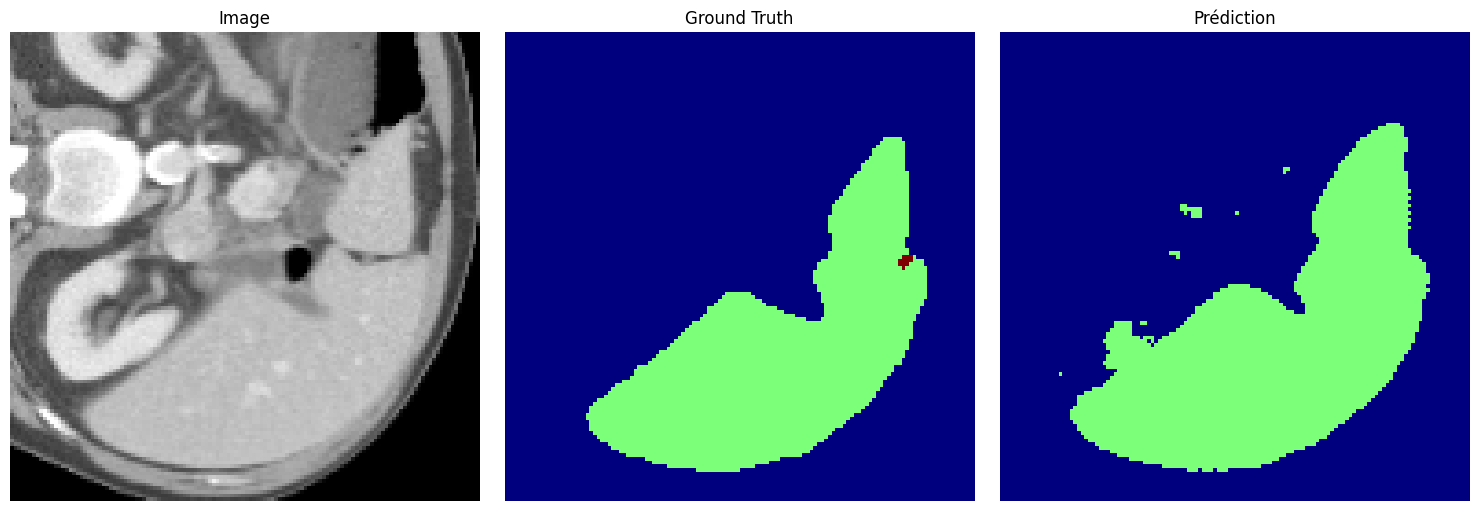

In [18]:
import matplotlib.pyplot as plt
import torch

model.eval()
sample = next(iter(test_loader))
vol   = sample["image"].to(device)
label = sample["label"]

with torch.no_grad():
    pred = model(vol)
    pred_class = torch.argmax(pred, dim=1)[0].cpu()  # [H,W,D]

vol_np   = vol[0, 0].cpu().numpy()
label_np = label[0, 0].numpy()
pred_np  = pred_class.numpy()

# Slice centrale
z = vol_np.shape[2] // 2

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(vol_np[:, :, z],   cmap='gray');        axes[0].set_title('Image')
axes[1].imshow(label_np[:, :, z], cmap='jet', vmin=0, vmax=2); axes[1].set_title('Ground Truth')
axes[2].imshow(pred_np[:, :, z],  cmap='jet', vmin=0, vmax=2); axes[2].set_title('Prédiction')
for ax in axes: ax.axis('off')
plt.tight_layout()
plt.show()

# Légende : 0=background, 1=foie, 2=tumeur